In [2054]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from functools import partial

import networkx as nx


@jax.jit
def find_ancestors_jax(mask, node):
    num_nodes = mask.shape[0]
    is_ancestor = jnp.zeros(num_nodes, dtype=jnp.bool_)
    stack = jnp.empty(num_nodes, dtype=jnp.int32)
    stack = stack.at[0].set(node)
    
    def body_fn(carry, i):
        is_ancestor, stack = carry
        current_node = stack[i]
        current_parents = mask[current_node, :]
        
        def inner_body_fn(carry, j):
            is_ancestor, stack = carry
            value = current_parents[j]
            cond = value & (j != current_node) & (~is_ancestor[j])
            
            def true_fn(is_ancestor, stack):
                is_ancestor = is_ancestor.at[j].set(True)
                stack = stack.at[i+1].set(j)
                return is_ancestor, stack
            def false_fn(is_ancestor, stack):
                return is_ancestor, stack
            
            is_ancestor, stack = jax.lax.cond(cond, true_fn, false_fn, is_ancestor, stack)
            return (is_ancestor, stack), None
        
        (is_ancestor, stack), _ = jax.lax.scan(inner_body_fn, (is_ancestor, stack), jnp.arange(num_nodes))
        return (is_ancestor, stack), None
    
    (is_ancestor, stack), _ = jax.lax.scan(body_fn, (is_ancestor, stack), jnp.arange(num_nodes))
    

    return is_ancestor


@jax.jit
def faithfull_mask(base_mask, condition_mask):
    """ Faithfull mask update for conditioning"""
    
    graph = base_mask.astype(jnp.bool_).copy()
    base_mask = base_mask.astype(jnp.bool_) # Rows are paraents, columns are children
    condition_mask = condition_mask.astype(jnp.bool_)
    num_nodes = base_mask.shape[0]
    
    def body_fn(carry, i):
        base_mask, condition_mask = carry
        
        def condition_case(base_mask, condition_mask):
            # We need to update all ancestors of i
            is_ancestor = find_ancestors_jax(graph, i)
            is_ancestor = is_ancestor & (~condition_mask)
            all_ancestors = jnp.nonzero(is_ancestor, size=num_nodes, fill_value=i)[0]
            # They will now depend on i
            base_mask = base_mask.at[all_ancestors,i].set(True)
            # They will now depend on each other!
            base_mask = base_mask | (is_ancestor[:,None] & is_ancestor[None,:])
            # The parents of all children of i will now depend on each other
            children_of_i = base_mask[:,i]
            parents_of_children_of_i = base_mask & (children_of_i[:,None] & ~children_of_i[None,:])
            parents_of_children_of_i = jnp.any(parents_of_children_of_i, axis=0)
            base_mask = base_mask | parents_of_children_of_i
            
            
        
            return base_mask, condition_mask
        
        def uncondition_case(base_mask, condition_mask):
            return base_mask, condition_mask
        
        base_mask, condition_mask = jax.lax.cond(condition_mask[i], condition_case, uncondition_case, base_mask, condition_mask)
        

        return (base_mask, condition_mask), None

    (base_mask, condition_mask), _ = jax.lax.scan(body_fn, (base_mask, condition_mask), jnp.arange(num_nodes))
        
    
    return base_mask
    
def convert_to_networkx(mask):
    """Converts a mask to a networkx graph"""
    return nx.from_numpy_array(mask - jnp.eye(mask.shape[0]), create_using=nx.DiGraph).reverse()

@jax.jit
def moralize(adj_matrix):
    adj_matrix = adj_matrix.astype(jnp.bool_)
    
    # Make the graph undirected
    undirected_graph = adj_matrix | adj_matrix.T
    
    # Add edges between parents
    undirected_graph = undirected_graph | (adj_matrix.T @ adj_matrix)
    
    return undirected_graph

def moralize_networkx(adj_matrix):
    return nx.to_numpy_array(nx.moral_graph(convert_to_networkx(adj_matrix))) != 0


@partial(jax.jit, static_argnums=(2,))
def minimally_faithfull_mask(mask, condition_mask, top_mode=0):
    """ Minimally faithfull mask update for conditioning"""
    num_nodes = mask.shape[0]
    I = moralize(mask)
    H = jnp.zeros_like(mask, dtype=jnp.bool_)
    # 0 is child, 1 is parent
    UPSTREAM = top_mode
    DOWNSTREAM = 1 - top_mode
    num_parents_or_childs = jnp.sum(mask & (~condition_mask[None, :] & ~condition_mask[:, None]), axis=UPSTREAM)
    #print(num_parents_or_childs)
    S = (num_parents_or_childs == 1) & (~condition_mask) # Frontier set
    M = jnp.zeros((num_nodes), dtype=jnp.bool_) # Marked nodes
    
    def cond_fn(val):
        S, _, _, _ = val
        return jnp.any(S) 
    
    def body_fn(val):
        S, M, I, H = val
        
        #print(S)
        # Find the node with the fewest edges added
        v = min_fill_heuristic(mask, I, S, top_mode)
        # Add edge in I between unmarked neighbours in I 
        neighbours_v = I[v,:] & (~M)
        I = I | (neighbours_v[:,None] & neighbours_v[None,:])
        # Make unmarked neighbours of v, the parents of v in H
        H = H.at[v,:].set(neighbours_v)
        # Remove v from S and mark it
        S = S.at [v].set(False)
        M = M.at[v].set(True)
        
        if top_mode == 1:
            u = mask[:,v] & (~M) # Not marked children
            upstream_u = mask & (u[:, None]  & ~u[None,:]) # Parents of not marked children
            all_upstream_u_marked = ~jnp.any(upstream_u & ~M, axis=1)
        else:
            u = mask[v,:] & (~M) # Not marked parents
            upstream_u = mask & (u[None,:]  & ~u[:, None]) # Children of not marked parents
            all_upstream_u_marked = ~jnp.any(upstream_u & ~M, axis=1)
        
        

        S = S | (u & all_upstream_u_marked)
        S = S & (~condition_mask)

          
        #print(v)
        # print("Marked: ", [labels[i] for i in jnp.nonzero(M)[0]])
        # if DOWNSTREAM == 1:
        #     print("v parents not marked: ", [labels[i] for i in jnp.nonzero(u)[0]])
        #     print("v parents children: ", [[labels[i] for i in jnp.nonzero(upstream_u[j,:])[0]] for j in jnp.nonzero(u)[0]])
        # else:
        #     print("vs children not marked: ", [labels[i] for i in jnp.nonzero(u)[0]])
        #     print("vs children parents: ", [[labels[i] for i in jnp.nonzero(upstream_u[j,:])[0]] for j in jnp.nonzero(u)[0]])
        
        
        
        return S, M, I, H
    
    _,_,_, H = jax.lax.while_loop(cond_fn, body_fn, (S, M, I, H))
    H = H | jnp.eye(num_nodes, dtype=jnp.bool_)
    
    # Conditioned nodes will keep the unconditional edges, hence each row of H where condition_mask is true should be equal to "mask"
    H = H & ~condition_mask[:, None] | mask & condition_mask[:, None]
    
    return H
    
                
        
    
    
@partial(jax.jit, static_argnums=(3,))
def min_fill_heuristic(G, I, S, top_mode=0):
    """ Min-fill heuristic for finding a node to eliminate"""
    
    # 0 is child, 1 is parent
    UPSTREAM = top_mode
    DOWNSTREAM = 1 - top_mode
    
    # Find the number of edges that would be added if we eliminated each node
    num_edges_added = I.sum(axis=DOWNSTREAM)
    num_edges_added = S * num_edges_added + (~S) * (I.shape[0] + 1)
    # Find the node that would add the fewest edges
    # Additional constraint: Given the above, find the node with the fewest parents
    min_val = jnp.min(num_edges_added)
    num_parents = G.sum(axis=UPSTREAM) * (num_edges_added == min_val) + (I.shape[0] + 1) * (num_edges_added != min_val)
    #print(num_edges_added + num_parents)
    node_to_eliminate = jnp.argmin(num_edges_added + num_parents)

    return node_to_eliminate 



In [2055]:
mask & jnp.array([0,1,0,0,0,0,0], dtype=jnp.bool_)[:,None]

TypeError: and got incompatible shapes for broadcasting: (20, 20), (7, 1).

In [2047]:
jnp.any(mask & mask[:,0], 1)

Array([ True, False,  True,  True], dtype=bool)

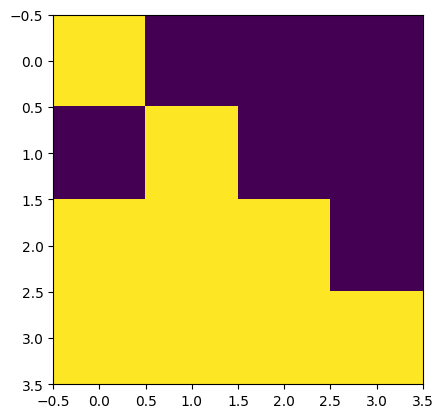

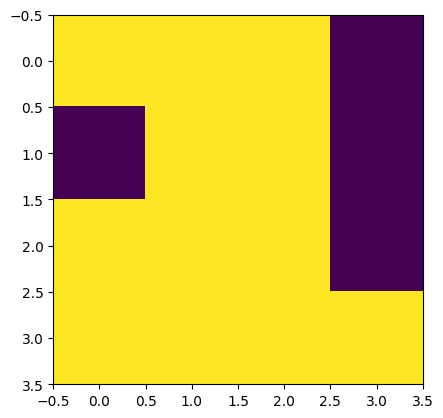

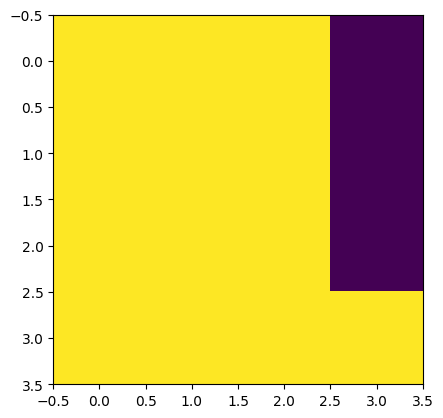

In [2048]:
# IID masks
mask1 = jnp.eye(2, dtype=jnp.bool_) 
mask2 = jnp.zeros((2,2), dtype=jnp.bool_)
mask3 = jnp.ones((2,2), dtype=jnp.bool_)
mask4 = jnp.eye(2, dtype=jnp.bool_) | jnp.eye(2, dtype=jnp.bool_, k=-1)
mask = jnp.block([[mask1, mask2], [mask3, mask4]])
with jax.disable_jit():
    
    plt.imshow(mask)
    plt.show()
    condition_mask = jnp.array([0]*4, dtype=jnp.bool_)
    condition_mask = condition_mask.at[2].set(True)
    plt.imshow(minimally_faithfull_mask(mask, condition_mask, top_mode=0))
    plt.show()
    plt.imshow(faithfull_mask(mask, condition_mask))

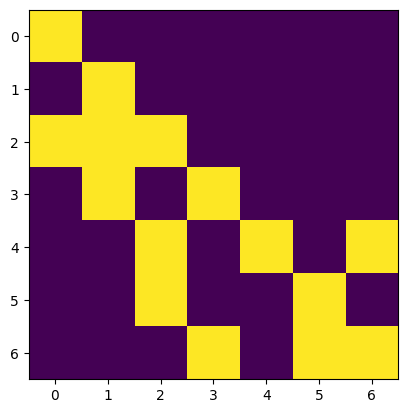

In [1879]:
plt.imshow(mask)

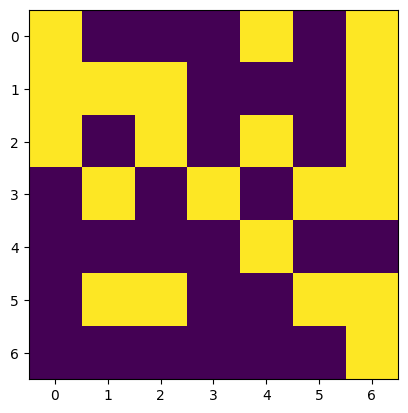

In [1880]:
plt.imshow(H)

/tmp/ipykernel_673/3832659210.py:35: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which hasknown issues and is not actively maintained. Consider usingnx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos = nx.drawing.nx_pydot.graphviz_layout(G, prog='dot')


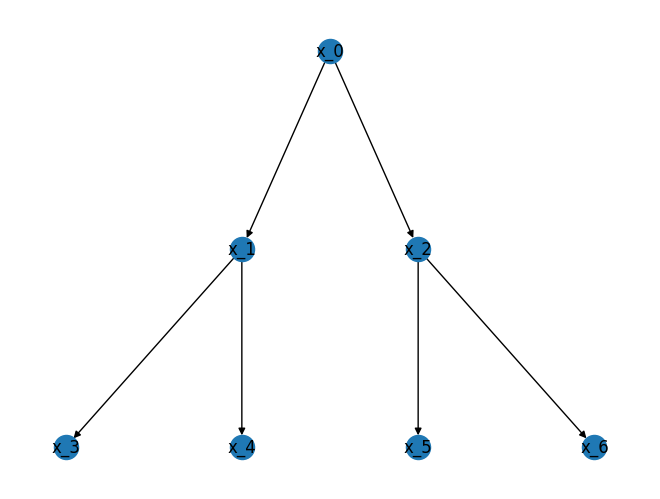

In [2057]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
# FILEPATH: /mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/examples/scoresbi/faithfull_mask.ipynb
# First two independent variables cause thrid and fourth
# mask = jnp.array([
#                   [1,0,0,0,0,0,0],  # D
#                   [0,1,0,0,0,0,0],  # I
#                   [1,1,1,0,0,0,0],  # G
#                   [0,1,0,1,0,0,0],  # S
#                   [0,0,1,0,1,0,1],  # H 
#                   [0,0,1,0,0,1,0],  # L
#                   [0,0,0,1,0,1,1]   # J
#                 ],dtype=jnp.bool_) 

mask = jnp.array([
                  [1,0,0,0,0,0,0],  # x_0
                  [1,1,0,0,0,0,0],  # x_1
                  [1,0,1,0,0,0,0],  # x_2
                  [0,1,0,1,0,0,0],  # x_3
                  [0,1,0,0,1,0,0],  # x_4
                  [0,0,1,0,0,1,0],  # x_5
                  [0,0,1,0,0,0,1]   # x_6
                ],dtype=jnp.bool_) 



#condition_mask = jnp.array([False, False, False, False, True, False, True])
condition_mask = jnp.array([False, False, False, True, True, True, True])

#labels = ['D', 'I', 'G', 'S', 'H', 'L', 'J']
labels = ['x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6']

G = convert_to_networkx(mask)
pos = nx.drawing.nx_pydot.graphviz_layout(G, prog='dot')

nx.draw(G, pos, with_labels=True, labels={i: labels[i] for i in range(mask.shape[0])})
plt.show()

In [2058]:

H = minimally_faithfull_mask(mask, condition_mask, top_mode=0)
    
nx.draw(convert_to_networkx(H), pos, with_labels=True, labels={i: labels[i] for i in range(mask.shape[0])})

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[].
The axis argument must be known statically.
The error occurred while tracing the function minimally_faithfull_mask at /tmp/ipykernel_673/513185813.py:111 for jit. This concrete value was not available in Python because it depends on the value of the argument top_mode.

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

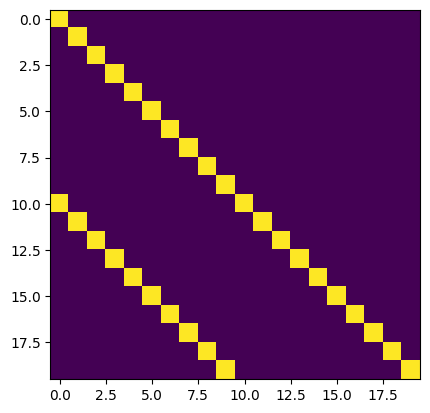

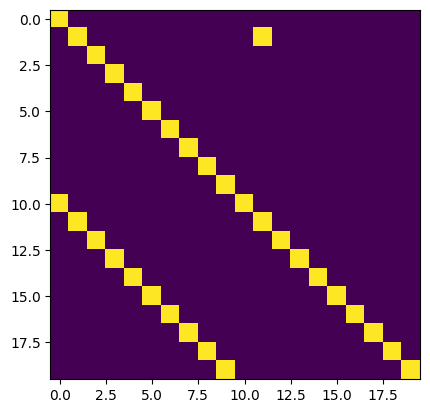

In [2051]:
# IID masks
mask1 = jnp.eye(10, dtype=jnp.bool_)
mask2 = jnp.zeros((10,10), dtype=jnp.bool_)
mask = jnp.block([[mask1, mask2], [mask1, mask1]])
plt.imshow(mask)
plt.show()
condition_mask = jnp.array([False] * 20, dtype=jnp.bool_)
condition_mask = condition_mask.at[11].set(True)
plt.imshow(minimally_faithfull_mask(mask, condition_mask, top_mode=0))

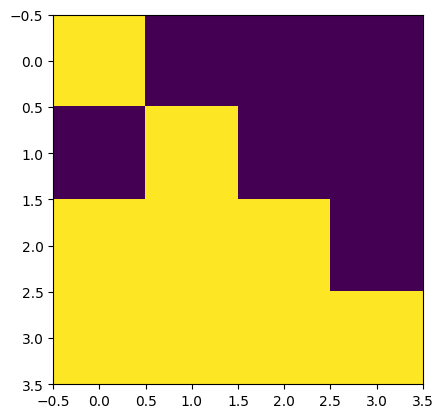

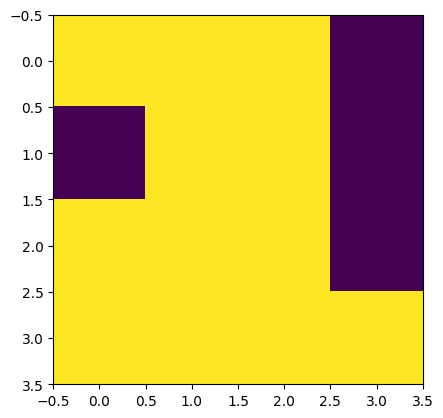

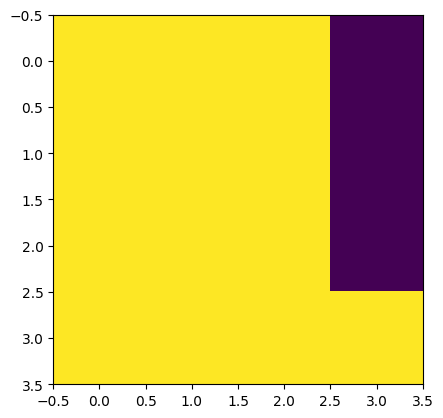

In [2052]:
# IID masks
dim = 2
mask1 = jnp.eye(dim, dtype=jnp.bool_) 
mask2 = jnp.zeros((dim,dim), dtype=jnp.bool_)
mask3 = jnp.ones((dim,dim), dtype=jnp.bool_)
mask4 = jnp.tril(jnp.ones((dim,dim), dtype=jnp.bool_))
mask = jnp.block([[mask1, mask2], [mask3, mask4]])
with jax.disable_jit():
    
    plt.imshow(mask)
    plt.show()
    condition_mask = jnp.array([0]*2*dim, dtype=jnp.bool_)
    condition_mask = condition_mask.at[2].set(True)
    plt.imshow(minimally_faithfull_mask(mask, condition_mask, top_mode=0) )
    plt.show()
    plt.imshow(faithfull_mask(mask, condition_mask))

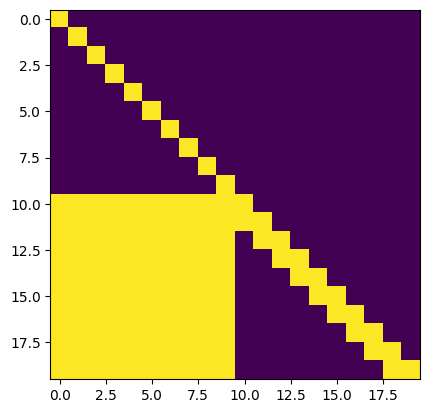

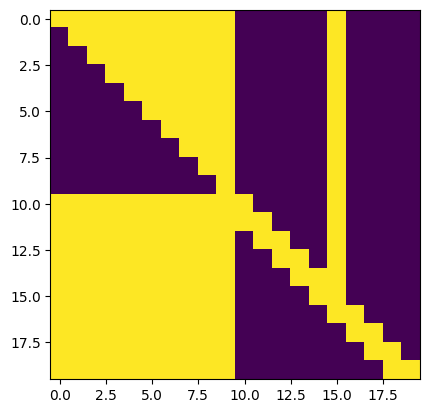

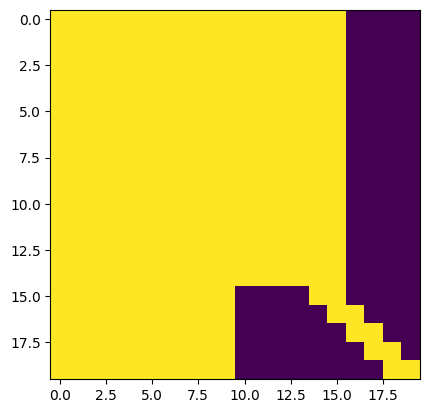

In [2053]:
# IID masks
dim = 10
mask1 = jnp.eye(dim, dtype=jnp.bool_) 
mask2 = jnp.zeros((dim,dim), dtype=jnp.bool_)
mask3 = jnp.ones((dim,dim), dtype=jnp.bool_)
mask4 = jnp.eye(dim, dtype=jnp.bool_) | jnp.eye(dim, dtype=jnp.bool_, k=-1)
mask = jnp.block([[mask1, mask2], [mask3, mask4]])
with jax.disable_jit():
    
    plt.imshow(mask)
    plt.show()
    condition_mask = jnp.array([0]*2*dim, dtype=jnp.bool_)
    condition_mask = condition_mask.at[15].set(True)
    plt.imshow(minimally_faithfull_mask(mask, condition_mask, top_mode=0) )
    plt.show()
    plt.imshow(faithfull_mask(mask, condition_mask))

In [1738]:
children_parents = jnp.any(mask & (u[:, None]  & ~u[None,:]), 0) 

for i in jnp.nonzero(children_parents)[0]:
    print(labels[i])

D
I


In [1739]:

u = mask[v, :] # Parents
u = u.at[v].set(False)
for i in jnp.nonzero(u)[0]:
    print(labels[i])

In [1711]:
parents_children = jnp.any(mask & (u[None,:]  & ~u[:, None]), 1) 

for i in jnp.nonzero(parents_children)[0]:
    print(labels[i])

G
S


v selected D
S ['I']
v selected I
S []


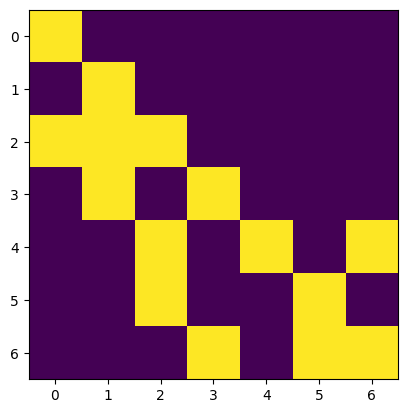

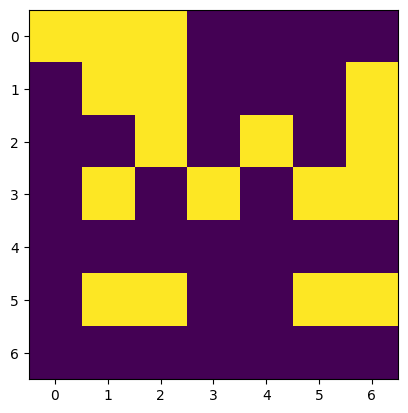

In [1313]:
plt.imshow(mask)
plt.show()
plt.imshow(H)

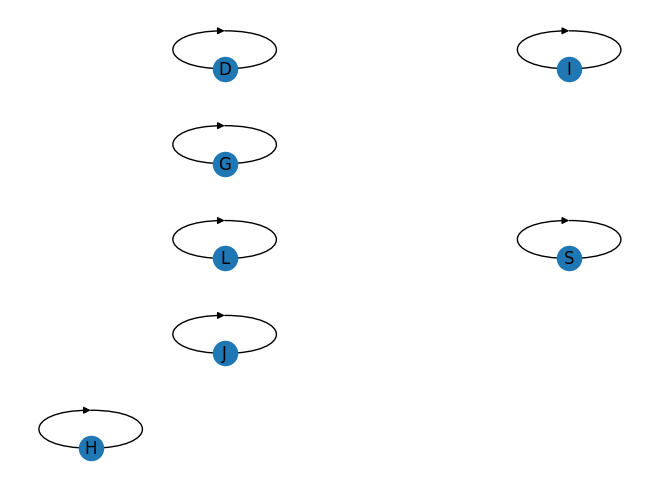

In [1254]:
nx.draw(convert_to_networkx(H), pos, with_labels=True, labels={i: labels[i] for i in range(mask.shape[0])})

In [1284]:
top_mode = 1

G = mask & ~jnp.eye(mask.shape[0], dtype=jnp.bool_) # Remove self loops
num_nodes = G.shape[0]
I = moralize(G)
H = jnp.zeros((num_nodes, num_nodes), dtype=jnp.bool_)
# 0 is child, 1 is parent
UPSTREAM = top_mode
DOWNSTREAM = 1 - top_mode
upstream_nodes = G.sum(axis=UPSTREAM) + condition_mask*(num_nodes + 1)
min_upstream_nodes = jnp.min(upstream_nodes)

S = (upstream_nodes == min_upstream_nodes) & (~condition_mask) # Frontier set
M = jnp.zeros((num_nodes), dtype=jnp.bool_) # Marked nodes

In [1285]:
v = min_fill_heuristic(I, S, top_mode)
# Add edge in I between unmarked neighbours in I 
neighbours_v = I[v,:] & (~M)

I = I | (neighbours_v[:,None] & neighbours_v[None,:])
H = H.at[v,:].set(neighbours_v)
# Remove v from S and mark it
S = S.at [v].set(False)
M = M.at[v].set(True)

In [1286]:
u = G[:, v] & (~M)

In [1287]:
mask & u[:,None]

Array([[False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False],
       [ True,  True,  True, False, False, False, False],
       [False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False]], dtype=bool)

In [1289]:
mask & u[None,:]

Array([[False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False],
       [False, False,  True, False, False, False, False],
       [False, False, False, False, False, False, False],
       [False, False,  True, False, False, False, False],
       [False, False,  True, False, False, False, False],
       [False, False, False, False, False, False, False]], dtype=bool)

In [1239]:

# First iteration

# Select node to eliminate
v = min_fill_heuristic(I, S, top_mode)
# Add edge in I between unmarked neighbours in I 
neighbours_v = I[v,:] & (~M)
I = I | (neighbours_v[:,None] & neighbours_v[None,:])
# Make unmarked neighbours of v, the parents of v in H
H = H.at[v,:].set(neighbours_v)
# Remove v from S and mark it
S = S.at [v].set(False)
M = M.at[v].set(True)

# Add all unmarked nodes, downstream of v, to S if all upstream nodes are marked
u = mask[:,v] & (~M)
upstream_u = (mask & u[:,None]) & ~u
upstream_not_marked = ~jnp.any(upstream_u & ~M,1)
S = S | (u & upstream_not_marked)
    
print(S)

# Second iteration
v = min_fill_heuristic(I, S, top_mode)
neighbours_v = I[v,:] & (~M)
I = I | (neighbours_v[:,None] & neighbours_v[None,:])
H = H.at[v,:].set(neighbours_v)
S = S.at [v].set(False)
M = M.at[v].set(True)

# # # Add all unmarked nodes, downstream of v, to S if all upstream nodes are marked
u = mask[:,v] & (~M)
upstream_u = (mask & u[:,None]) & ~u
upstream_not_marked = ~jnp.any(upstream_u & ~M,1)
S = S | (u & upstream_not_marked)

print(S)

# Third iteration
v = min_fill_heuristic(I, S, top_mode)
neighbours_v = I[v,:] & (~M)
I = I | (neighbours_v[:,None] & neighbours_v[None,:])
H = H.at[v,:].set(neighbours_v)
S = S.at [v].set(False)
M = M.at[v].set(True)

# # # Add all unmarked nodes, downstream of v, to S if all upstream nodes are marked
u = mask[:,v] & (~M)
upstream_u = (mask & u[:,None]) & ~u
upstream_not_marked = ~jnp.any(upstream_u & ~M,1)
S = S | (u & upstream_not_marked)

print(S)

# Fourth iteration
v = min_fill_heuristic(I, S, top_mode)
neighbours_v = I[v,:] & (~M)
I = I | (neighbours_v[:,None] & neighbours_v[None,:])
H = H.at[v,:].set(neighbours_v)
S = S.at [v].set(False)
M = M.at[v].set(True)

# # # Add all unmarked nodes, downstream of v, to S if all upstream nodes are marked
u = mask[:,v] & (~M)
upstream_u = (mask & u[:,None]) & ~u
upstream_not_marked = ~jnp.any(upstream_u & ~M,1)
S = S | (u & upstream_not_marked)

print(S)

# Fith iteration
v = min_fill_heuristic(I, S, top_mode)
neighbours_v = I[v,:] & (~M)
I = I | (neighbours_v[:,None] & neighbours_v[None,:])
H = H.at[v,:].set(neighbours_v)
S = S.at [v].set(False)
M = M.at[v].set(True)

# # # Add all unmarked nodes, downstream of v, to S if all upstream nodes are marked
u = mask[:,v] & (~M)
upstream_u = (mask & u[:,None]) & ~u
upstream_not_marked = ~jnp.any(upstream_u & ~M,1)
S = S | (u & upstream_not_marked)

print(S)

[False  True False False False False False]
[False False  True  True False False False]
[False False  True False False False False]
[False False False False False  True False]
[False False False False False False  True]


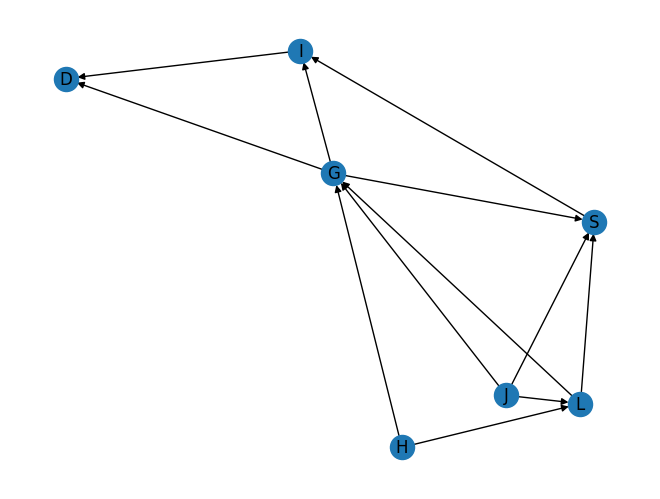

In [1182]:
nx.draw(convert_to_networkx(H), with_labels=True, labels={i: labels[i] for i in range(mask.shape[0])})

In [1171]:
jnp.any(upstream_u & ~M, -1)

Array([False, False,  True, False, False, False, False], dtype=bool)

In [917]:
jnp.finfo

ValueError: data type <class 'numpy.int64'> not inexact

In [947]:
v

Array(1, dtype=int32)

In [720]:
find_ancestors_jax(mask1, 2)[:, None] @ find_ancestors_jax(mask1, 2)[None, :]

Array([[ True,  True, False],
       [ True,  True, False],
       [False, False, False]], dtype=bool)

In [713]:
faithfull_mask(mask1, jnp.array([False, False, True]))

Array([[ True,  True,  True],
       [ True,  True,  True],
       [False, False, False]], dtype=bool)

In [703]:
# 3 node chain
mask1 = jnp.array([[1, 0, 0], [1, 1, 0], [0, 1, 1]], dtype=jnp.bool_)
# 3 node fork
mask2 = jnp.array([[1, 1, 0], [0, 1, 0], [0, 1, 1]], dtype=jnp.bool_)
# 3 node collider
mask3 = jnp.array([[1, 0, 0], [1, 1, 1], [0, 0, 1]], dtype=jnp.bool_)

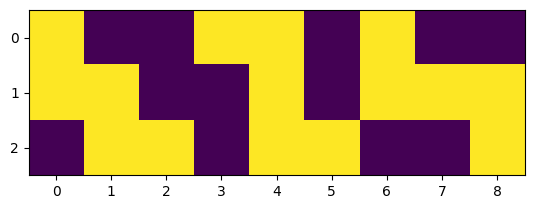

In [704]:
plt.imshow(jnp.concatenate([mask1, mask2, mask3], axis=1))

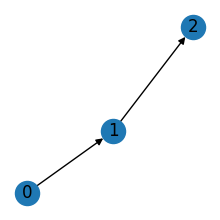

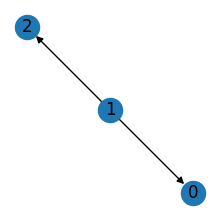

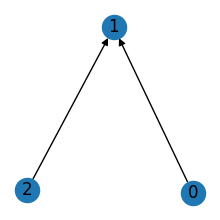

In [572]:
for m in [mask1, mask2, mask3]:
 
    fig = plt.figure(figsize=(2,2))
    nx.draw(convert_to_networkx(m), with_labels=True)
    plt.show()

In [699]:
g = convert_to_networkx(mask1)
nx.d_separated(g, {1}, {2}, {})

False

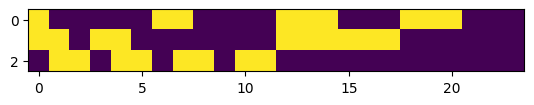

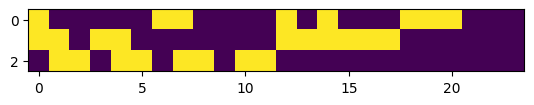

In [721]:
all_condition_masks = jnp.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0], [0, 0, 1], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=jnp.bool_)
all_condition_graphs = [faithfull_mask(mask1, condition_mask) for condition_mask in all_condition_masks]
all_condition_graphs_true = [networkx_faithfull_mask(mask1, condition_mask) for condition_mask in all_condition_masks]
plt.imshow(jnp.concatenate(all_condition_graphs, axis=1), vmin=0, vmax=1)
plt.show()
plt.imshow(jnp.concatenate(all_condition_graphs_true, axis=1), vmin=0, vmax=1)

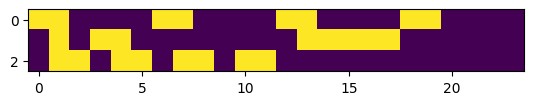

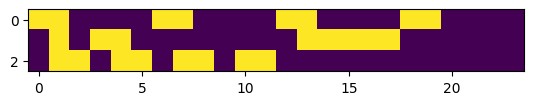

In [722]:
all_condition_masks = jnp.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0], [0, 0, 1], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=jnp.bool_)
all_condition_graphs = [faithfull_mask(mask2, condition_mask) for condition_mask in all_condition_masks]
all_condition_graphs_true = [networkx_faithfull_mask(mask2, condition_mask) for condition_mask in all_condition_masks]
plt.imshow(jnp.concatenate(all_condition_graphs, axis=1))
plt.show()
plt.imshow(jnp.concatenate(all_condition_graphs_true, axis=1))

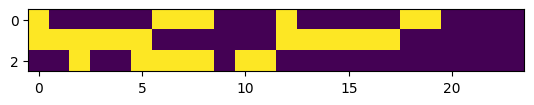

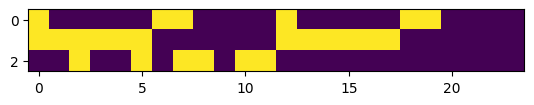

In [723]:
all_condition_masks = jnp.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0], [0, 0, 1], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=jnp.bool_)
all_condition_graphs = [faithfull_mask(mask3, condition_mask) for condition_mask in all_condition_masks]
all_condition_graphs_true = [networkx_faithfull_mask(mask3, condition_mask) for condition_mask in all_condition_masks]
plt.imshow(jnp.concatenate(all_condition_graphs, axis=1))
plt.show()
plt.imshow(jnp.concatenate(all_condition_graphs_true, axis=1))